In [104]:
import src.preprocessing.load_csv as load_csv
import src.preprocessing.plot_data as plot_data
import src.preprocessing.preprocessing_run as preprocessing_run
import src.models.T2_model as T2_model
import src.evaluation.predict as predict
import src.preprocessing.tools as tools
import src.preprocessing.kowalski as kowalski
import src.evaluation.plot_evaluation as plot_evaluation
import src.preprocessing.gaussian_process as gp

import importlib
import numpy as np
import pandas as pd

importlib.reload(load_csv)
importlib.reload(plot_data)
importlib.reload(preprocessing_run)
importlib.reload(T2_model)
importlib.reload(predict)
importlib.reload(tools)
importlib.reload(kowalski)
importlib.reload(plot_evaluation)
importlib.reload(gp)

<module 'src.preprocessing.gaussian_process' from '/home/theob/Documents/stage/ML_skyportal/src/preprocessing/gaussian_process.py'>

In [36]:
path = '/media/theob/E/ML_project_data/data_kowalski/'
kowalski.get_data_from_kowalski(all=True, dataDir=path)

Connected to Kowalski
Total number of objects: 14153
0 ZTF17aaaeqms 0.0
1 ZTF17aaajowi 7.065639793683318e-05
2 ZTF17aaanztg 0.00014131279587366636
3 ZTF17aaaocnx 0.00021196919381049955
4 ZTF17aaaptxx 0.0002826255917473327
5 ZTF17aaapufz 0.0003532819896841659
6 ZTF17aaazdba 0.0004239383876209991
7 ZTF17aabgaoo 0.0004945947855578322
8 ZTF17aabhmby 0.0005652511834946654
9 ZTF17aabtvsy 0.0006359075814314987
10 ZTF17aabwkio 0.0007065639793683318
11 ZTF17aacldgo 0.000777220377305165
12 ZTF17aacpbmv 0.0008478767752419982
13 ZTF17aacxacr 0.0009185331731788313
14 ZTF17aadlxmv 0.0009891895711156644
15 ZTF18aaaecnk 0.0010598459690524978
16 ZTF18aaaehwv 0.0011305023669893309
17 ZTF18aaahyvk 0.001201158764926164
18 ZTF18aaaibml 0.0012718151628629973
19 ZTF18aaajljy 0.0013424715607998304
20 ZTF18aaanaev 0.0014131279587366635
21 ZTF18aaaonon 0.0014837843566734969
22 ZTF18aaaqbhp 0.00155444075461033
23 ZTF18aaaqexr 0.001625097152547163
24 ZTF18aaaqgyc 0.0016957535504839964
25 ZTF18aabcgyb 0.0017664099

KeyboardInterrupt: 

# Load data

In [5]:
bts_df = load_csv.load_BTS_data('data/BTS.csv')
bts_df = bts_df[['objectId', 'type']]
bts_df

,objectId,type
0,ZTF17aaaeqms,-
1,ZTF17aaajowi,-
2,ZTF17aaanztg,-
3,ZTF17aaaocnx,-
4,ZTF17aaaptxx,-
...,...,...
14148,ZTF24aaguphd,-
14149,ZTF24aagwfly,-
14150,ZTF24aagwwkr,-
14151,ZTF24aagzzye,-


In [4]:
import os
objIds = os.listdir(path)

photo_df, object_alerts = kowalski.load_kowalski_data(objIds[0], path)

# Get one Object

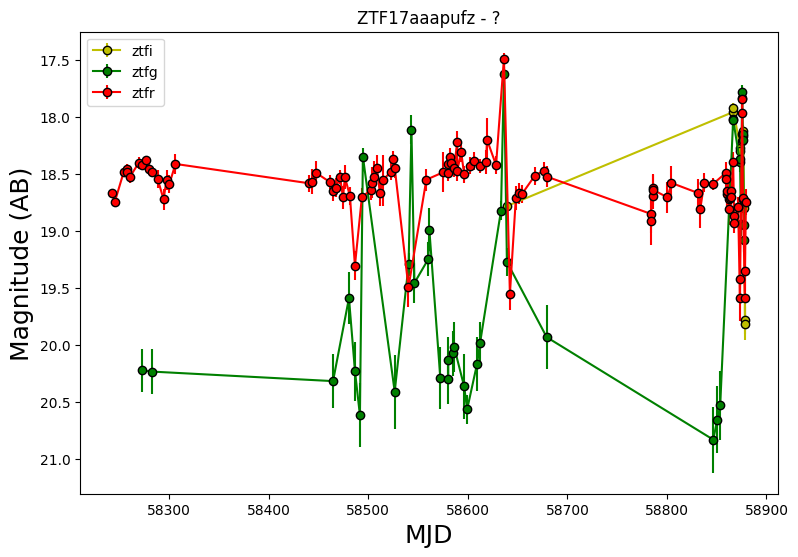

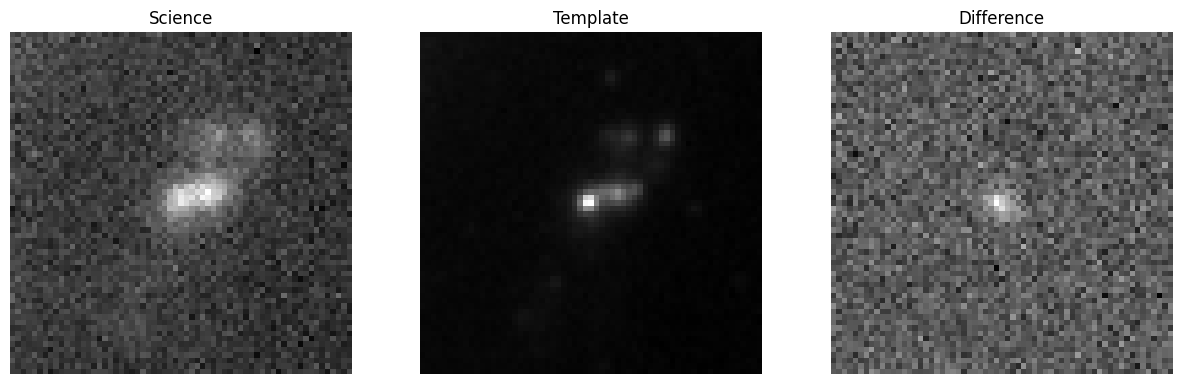

       objectId  sgscore1  sgscore2  distpsnr1  distpsnr2  fwhm     magpsf  \
0  ZTF17aaapufz   0.06775       0.5   0.358745   1.052879   5.8  18.880783   

   sigmapsf          ra        dec  diffmaglim  ndethist  nmtchps  ncovhist  \
0  0.141812  188.967762  27.931996   19.827234       312       19       555   

   sharpnr      scorr       sky  
0    0.173  13.838647 -0.050174  


In [6]:
one_photo, one_metadata, one_image, index = kowalski.get_data(photo_df, object_alerts, index=300)
plot_data.plot_all(one_photo, one_metadata, one_image)

In [7]:
def count_points_by_filter(df):
    count_df = df.groupby(['obj_id', 'filter']).size().unstack(fill_value=0)
    count_df = count_df[['ztfr', 'ztfg', 'ztfi']]
    return count_df

In [8]:
result = count_points_by_filter(one_photo)
print(result)

filter        ztfr  ztfg  ztfi
obj_id                        
ZTF17aaapufz    97    40    13


# Preprocessing

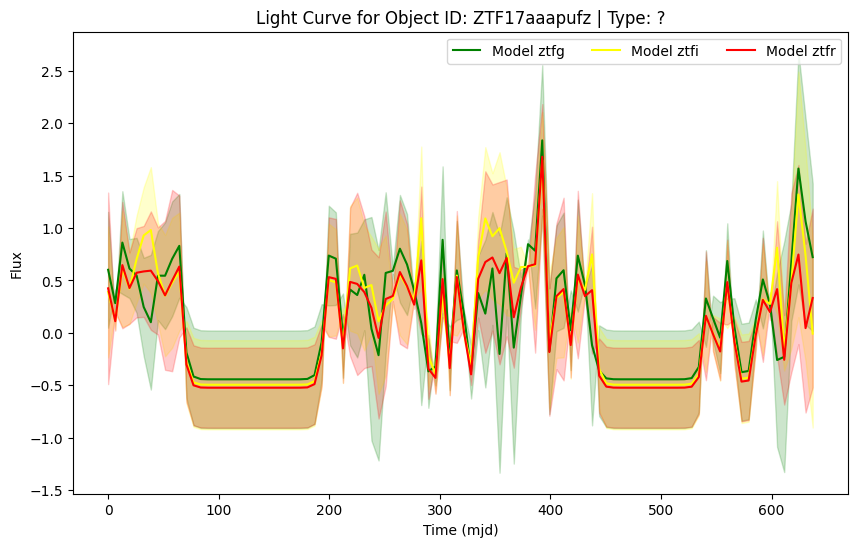

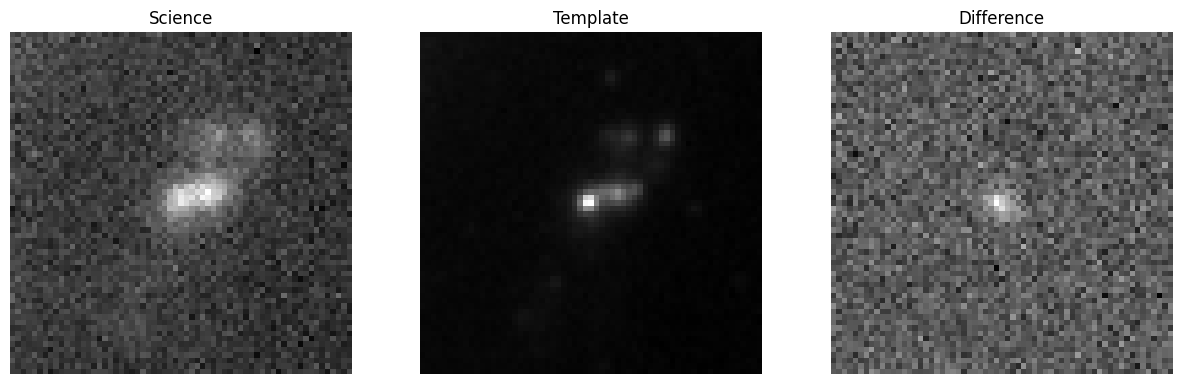

In [10]:
photo_ready, cand_ready, image_ready = preprocessing_run.process_data(one_photo, one_metadata, one_image, verbose=True)

# Load model

In [46]:
from tensorflow.keras.optimizers import Adam

num_filters = 64
num_classes = 2
num_layers = 1
d_model = 64
num_heads = 16
dff = 128
rate = 0.5

shapes = [(100, 4), (16,), (63, 63, 3)]

# Initialize the T2Model with the proper configuration
model = T2_model.T2Model(num_filters=num_filters, num_classes=num_classes, num_layers=num_layers,
                d_model=d_model, num_heads=num_heads, dff=dff, input_shapes=shapes, 
                rate=rate)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])

# Creating the final model instance
model.build(input_shapes=shapes)

# Print the model summary
model.summary()

model.load_weights('checkpoints/step_1.weights.h5')

2024-06-12 17:36:59.357833: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-12 17:37:02.284414: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "t2_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ multimodal_model                │ (None, 1)              │       226,673 │
│ (MultimodalModel)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_embedding (ConvEmbedding)  │ (None, 100, 64)        │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 100, 64)        │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 100, 64)        │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 65)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate_1 (Concatenate)     │ (None, 65)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,109 (1019.96 KB)

 Trainable params: 261,077 (1019.83 KB)

 Non-trainable params: 32 (128.00 B)

/home/theob/anaconda3/envs/ml_skyportal_env/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:396: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 78 variables. 
  trackable.load_own_variables(weights_store.get(inner_path))


In [12]:
final_data = predict.predict_classes(photo_ready, cand_ready, image_ready)

In [13]:
print(final_data[0].shape, final_data[1].shape, final_data[2].shape)

(1, 100, 4) (1, 16) (1, 63, 63, 3)


# Predict and display

In [14]:
y_pred, y_pred_classes = predict.predict_T2(final_data, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [17]:
types = ['Other', 'SN']

print(f'The object is a {types[y_pred_classes[0]]} with a probability of {y_pred[0][y_pred_classes[0]]:.2f}')

The object is a SN with a probability of 0.85


# Loop

In [106]:
def merge_filter_counts(dict_list):
    merged_dict = {}
    for d in dict_list:
        merged_dict.update(d)
    return merged_dict

def count_points_by_filter(df, alert_num):
    count_df = df.groupby(['filter']).size().reindex(['ztfr', 'ztfg', 'ztfi'], fill_value=0)
    return {alert_num: count_df.to_dict()}

In [107]:
from tqdm import tqdm

def prepare_all_data(photo_df, object_alerts, nb_max=None):
    df_photometry = pd.DataFrame()
    df_metadata = pd.DataFrame()
    all_images = []

    counts_dict = {}
    
    index = 0
    max_index = nb_max if nb_max is not None else len(object_alerts)
    
    shape_image_expected = (63, 63, 3)
    with tqdm(total=max_index, desc="Processing alerts") as pbar:
        while index < max_index:
            one_photo, one_metadata, one_image, index = kowalski.get_data(photo_df, object_alerts, index=index)

            nb_filter = count_points_by_filter(one_photo, index)
            counts_dict = merge_filter_counts([counts_dict, nb_filter])

            if one_image.shape == shape_image_expected:
                photo_ready, cand_ready, image_ready = preprocessing_run.process_data(one_photo, one_metadata, one_image, verbose=False)
            
                photo_ready['obj_id'] = index
                cand_ready['obj_id'] = index

                df_photometry = pd.concat([df_photometry, photo_ready], ignore_index=True)
                df_metadata = pd.concat([df_metadata, cand_ready], ignore_index=True)
                all_images.append(image_ready)

            index += 1
            pbar.update(1)
    
    all_images = np.concatenate(all_images, axis=0)
    
    return df_photometry, df_metadata, all_images, counts_dict

In [261]:
def predict_all(photo_df, object_alerts, model, nb_max=None, types=['type 1', 'type 2']):

    all_photometry, all_metadata, all_images, counts_dict = prepare_all_data(photo_df, object_alerts, nb_max=nb_max)

    final_data = predict.predict_classes(all_photometry, all_metadata, all_images)

    print(final_data[0].shape, final_data[1].shape, final_data[2].shape)
    
    y_pred, y_pred_classes = predict.predict_T2(final_data, model)

    df_results = pd.DataFrame(y_pred, columns=['type_1', 'type_2'])
    df_results['prediction'] = y_pred_classes
    df_results['alertes'] = all_photometry['obj_id'].unique()
    df_results = df_results[['alertes', 'type_1', 'type_2', 'prediction']]
    
    #plot_evaluation.plot_supernova_classification(df_results, types=types)
    plot_evaluation.plot_interactive_supernova_classification(df_results, types=types, counts_dict=counts_dict)

    count_type_1 = df_results['prediction'].value_counts()[0]
    count_type_2 = df_results['prediction'].value_counts()[1]
    print(f'Type 1: {count_type_1}, Type 2: {count_type_2}')
    
    if count_type_1 == count_type_2:
        print(f'Equal number of type 1 and type 2')
    else:
        print(f'The object is a {types[df_results["prediction"].value_counts().idxmax()]}')

    #sum des type_1 et type_2
    type_1 = df_results['type_1'].sum()
    type_2 = df_results['type_2'].sum()

    print(f'Type 1: {type_1}, Type 2: {type_2}')
    
    final_prediction = types[0] if type_1 > type_2 else types[1]
    print(f'Final prediction: {final_prediction}')

    
    return df_results, counts_dict

In [144]:
import os
objIds = os.listdir(path)
print(objIds)

['ZTF18aayiahw', 'ZTF18aayidfz', 'ZTF18aayiono', 'ZTF18aayivoq', 'ZTF18aayivxm', 'ZTF18aayjflv', 'ZTF18aayjvve', 'ZTF18aayjyub', 'ZTF18aaykjei', 'ZTF18aaykmzg', 'ZTF18aaylbjm', 'ZTF18aaylcvo', 'ZTF18aaypxlu', 'ZTF18aaytovs', 'ZTF18aayxupv', 'ZTF18aayyqia', 'ZTF18aayyxxp', 'ZTF18aazabmh', 'ZTF18aazblzy', 'ZTF18aazcoob', 'ZTF18aazgfkq', 'ZTF18aazhklh', 'ZTF17aaaeqms', 'ZTF17aaajowi', 'ZTF17aaanztg', 'ZTF17aaaocnx', 'ZTF17aaaptxx', 'ZTF17aaapufz', 'ZTF17aaazdba', 'ZTF17aabgaoo', 'ZTF17aabhmby', 'ZTF17aabtvsy', 'ZTF17aabwkio', 'ZTF17aacldgo', 'ZTF17aacpbmv', 'ZTF17aacxacr', 'ZTF17aadlxmv', 'ZTF18aaaecnk', 'ZTF18aaaehwv', 'ZTF18aaaibml', 'ZTF18aaajljy', 'ZTF18aaanaev', 'ZTF18aaaonon', 'ZTF18aaaqbhp', 'ZTF18aaaqexr', 'ZTF18aaaqgyc', 'ZTF18aabcgyb', 'ZTF18aabdajx', 'ZTF18aabdgik', 'ZTF18aabdjmb', 'ZTF18aabedfq', 'ZTF18aabezhk', 'ZTF18aabgroi', 'ZTF18aabiwhf', 'ZTF18aabkvpi', 'ZTF18aabssth', 'ZTF18aabtxvd', 'ZTF18aabuoud', 'ZTF18aabuoxd', 'ZTF18aabutpp', 'ZTF18aabxlsv', 'ZTF18aabxyys', 'ZTF18a

In [110]:
len(objIds)

'ZTF18aayiahw'

In [298]:
# type de l'obj dans bts_df
nb_id = 42
bts_df[bts_df['objectId'] == objIds[nb_id]]['type'].values[0]

'SN Ia'

In [299]:
photo_df, object_alerts = kowalski.load_kowalski_data(objIds[nb_id], path)
len(object_alerts)

14

In [300]:
counts = count_points_by_filter(photo_df, 100)
if all(counts[filter] < 3 for filter in counts):
    print(f"No filter has at least 3 points for object {objIds[nb_id]}. Skipping.")

TypeError: '<' not supported between instances of 'dict' and 'int'

In [287]:
count_points_by_filter(photo_df, 100)

{100: {'ztfr': 2, 'ztfg': 2, 'ztfi': 0}}

In [271]:
df_result, counts_dict = predict_all(photo_df, object_alerts, model, nb_max=len(object_alerts), types=['Other', 'SN'])

Processing alerts:   1%|          | 2/283 [00:00<00:41,  6.77it/s]

Provided index 0 is less than the first valid index 159. Setting index to 159.


Processing alerts:  44%|████▍     | 124/283 [00:26<00:34,  4.67it/s]


(124, 100, 4) (124, 16) (124, 63, 63, 3)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


Type 1: 57, Type 2: 67
The object is a SN
Type 1: 61.93694305419922, Type 2: 64.32178497314453
Final prediction: SN


In [302]:
def has_valid_filter(counts_dict):
    for obj_id, filters in counts_dict.items():
        if any(count >= 3 for count in filters.values()):
            return True
    return False

In [301]:
# test has_valid_filter

counts = count_points_by_filter(photo_df, 100)
print(counts)
if not has_valid_filter(counts):
    print(f"At least one filter has at least 3 points for object {objIds[nb_id]}.")

{100: {'ztfr': 11, 'ztfg': 17, 'ztfi': 0}}


In [303]:
def loop_on_all(objIds, model):

    df_result = pd.DataFrame()

    types = ['Other', 'SN']

    for nb_id in range(len(objIds)):
        try:
            # Charger les données
            photo_df, object_alerts = kowalski.load_kowalski_data(objIds[nb_id], path)

            nb_max = len(object_alerts) if len(object_alerts) < 301 else 301

            # Compter les points par filtre
            counts = count_points_by_filter(photo_df, nb_max)

            if not has_valid_filter(counts):
                continue

            # Effectuer les prédictions
            df_result, counts_dict = predict_all(photo_df, object_alerts, model, nb_max=nb_max, types=types)

            # Obtenir la vraie classe
            true_class = bts_df[bts_df['objectId'] == objIds[nb_id]]['type'].values[0]

            # Imprimer les résultats
            print(f'True class: {true_class}')
            print('---------------------')

            # Sauvegarder les résultats
            df_result['objectId'] = objIds[nb_id]
            df_result['true_class'] = true_class
            df_result['nb_predictions_type_1'] = df_result['prediction'].value_counts()[0]
            df_result['nb_predictions_type_2'] = df_result['prediction'].value_counts()[1]
            df_result['nb_type_1'] = df_result['type_1'].sum()
            df_result['nb_type_2'] = df_result['type_2'].sum()

            df_result['final_prediction_by_counts'] = types[df_result['prediction'].value_counts().idxmax()]
            df_result['final_prediction_by_sum'] = types[0] if df_result['nb_type_1'] > df_result['nb_type_2'] else types[1]

        except Exception as e:
            print(f"Error processing object {objIds[nb_id]}: {e}")
            continue

In [304]:
df_res = loop_on_all(objIds, model)

Error processing object ZTF18aayiahw: "None of [Index(['obj_id', 'mjd', 'mag', 'magerr', 'snr', 'limiting_mag', 'filter'], dtype='object')] are in the [columns]"
No filter has at least 3 points for object ZTF18aayidfz. Skipping.


Processing alerts:  12%|█▏        | 3/26 [00:00<00:00, 27.34it/s]

Provided index 0 is less than the first valid index 3. Setting index to 3.


Processing alerts:  88%|████████▊ | 23/26 [00:01<00:00, 15.54it/s]


(23, 100, 4) (23, 16) (23, 63, 63, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


...

Type 1: 22, Type 2: 53
The object is a SN
Type 1: 24.510215759277344, Type 2: 50.13740921020508
Final prediction: SN
True class: SN Ia
---------------------
Error processing object ZTF18aamvfeb: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().


Processing alerts:   0%|          | 0/56 [00:00<?, ?it/s]

Provided index 0 is less than the first valid index 11. Setting index to 11.


Processing alerts:  62%|██████▎   | 35/56 [00:04<00:02,  7.59it/s]


KeyboardInterrupt: 

In [305]:
df_res

NameError: name 'df_res' is not defined

# Predict random obj

Real Type: SN I


100%|██████████| 1/1 [00:00<00:00, 11.61it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


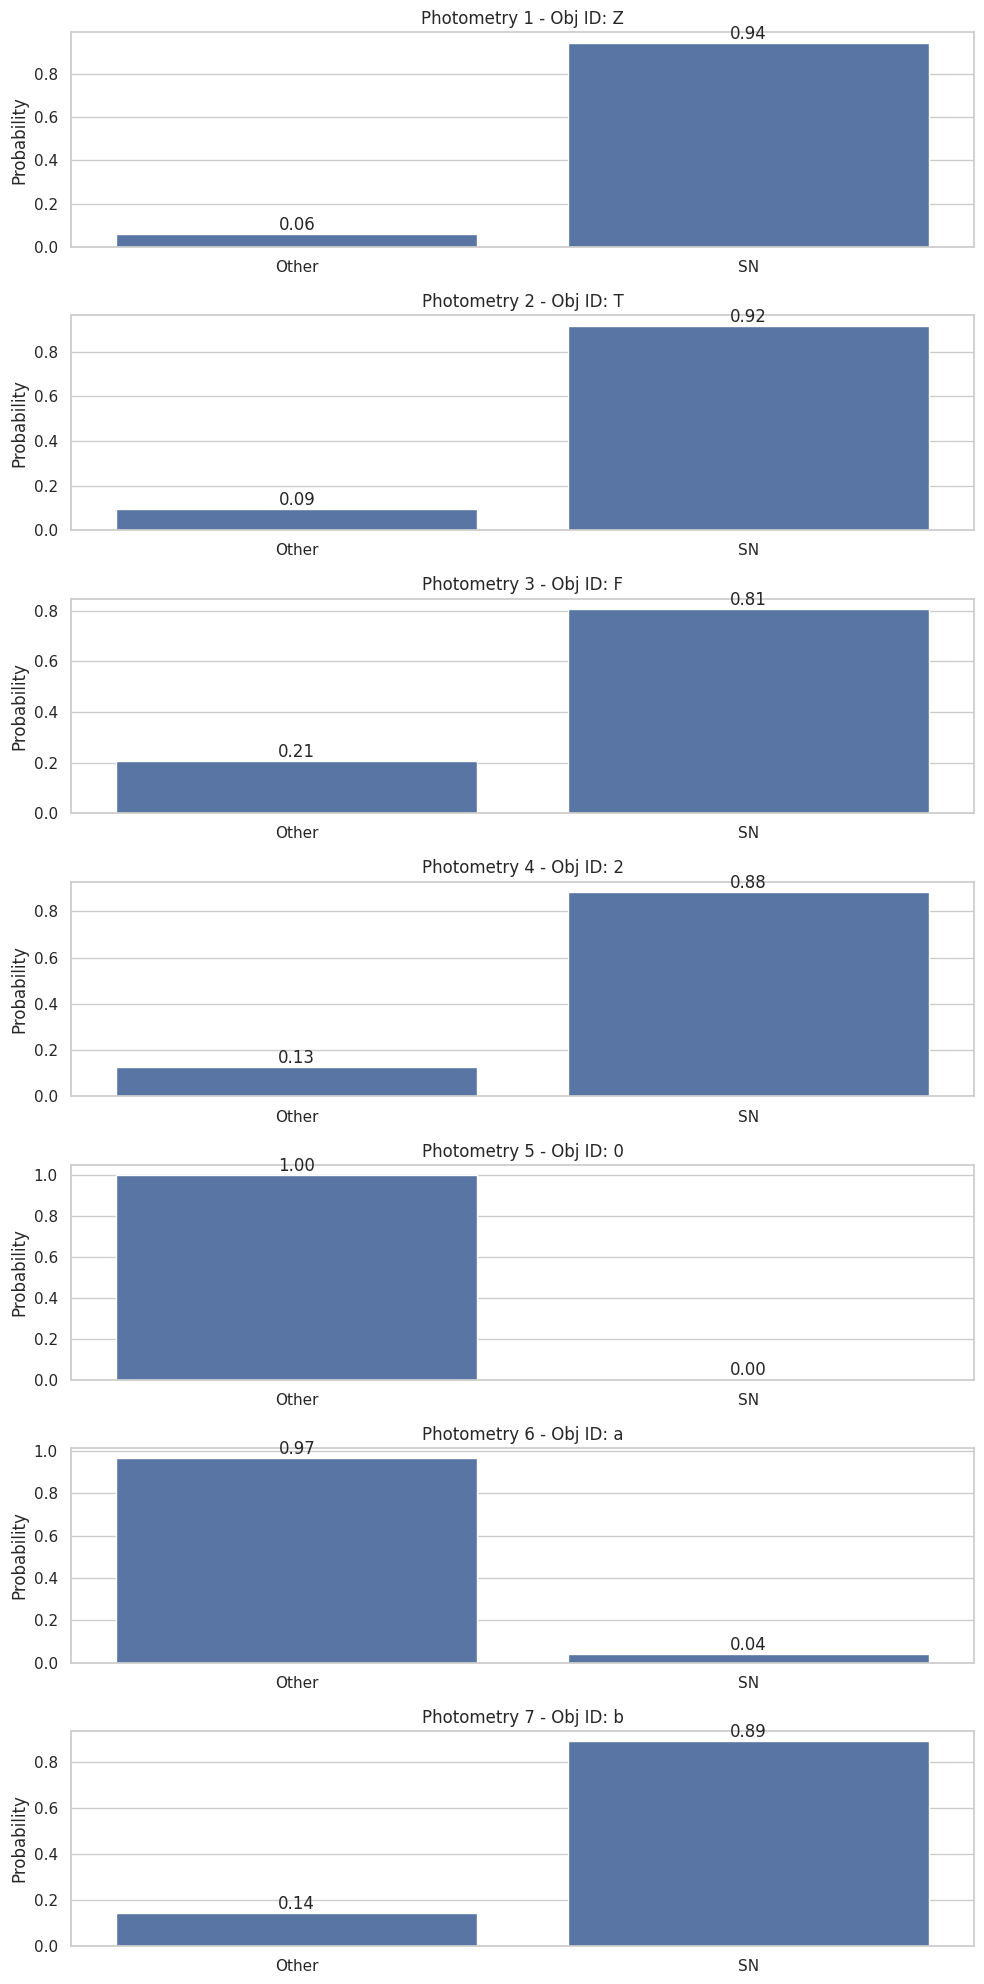

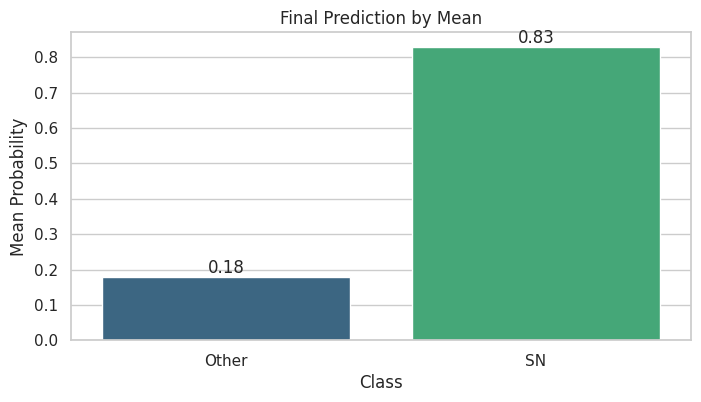

Final Prediction by Mean: [0.17900502 0.82930341]
Final Class by Voting: SN
Predicted Type: SN | Real Type: SN I


In [80]:
objId = load_csv.get_objId(objIds)
one_photo, one_cand, one_image = load_csv.get_data(objId, photo_df, cand, triplets)

real_type = one_photo['type'].iloc[0]
print(f"Real Type: {real_type}")

photo_ready, cand_ready, image_ready = preprocessing_run.process_data(one_photo, one_cand, one_image)
photo_ready.head()

final_data = predict.predict_classes(photo_ready, cand_ready, image_ready)

y_pred, y_pred_classes = predict.predict_T2(final_data, model)

predict.display_predictions(y_pred, objId, types)

weights = np.array([0.6, 0.1, 0.1, 0.05, 0.05, 0.05, 0.05])
weights = weights / np.sum(weights)
types = ['Other', 'SN']

final_prediction = predict.weighted_average_predictions(y_pred, weights)
if final_prediction is not None:
    predict.final_prediction_display(final_prediction, types)
    final_class = np.argmax(final_prediction)
    print(f"Final Prediction by Mean:", final_prediction)
    print(f"Final Class by Voting:", types[final_class])
else:
    print("No valid predictions available.")

print(f'Predicted Type: {types[final_class]} | Real Type: {real_type}')

# Predict and calculate success rate

In [83]:
obj_ids = objIds[:20]

In [88]:
from tqdm import tqdm

def calculate_success_rate(objIds, photo_df, cand, triplets, model, treshold=0.6):
    total_objects = len(objIds)
    successful_predictions = 0
    successful_high_confidence_predictions = 0
    high_confidence_predictions = 0
    incorrect_predictions = []
    confidence_correct = []
    confidence_incorrect = []
    logs = []

    types = ['Other', 'SN']
    weights = np.array([0.6, 0.1, 0.1, 0.05, 0.05, 0.05, 0.05])
    weights = weights / np.sum(weights)

    for objId in tqdm(objIds, desc="Processing Objects"):
        try:
            one_photo, one_cand, one_image = load_csv.get_data(objId, photo_df, cand, triplets)
            
            real_type = one_photo['type'].iloc[0].split()[0]

            photo_ready, cand_ready, image_ready = preprocessing_run.process_data(one_photo, one_cand, one_image)

            final_data = predict.predict_classes(photo_ready, cand_ready, image_ready)

            y_pred, y_pred_classes = predict.predict_T2(final_data, model)

            if y_pred.size == 0:
                logs.append(f"No valid predictions available for objId: {objId}")
                continue

            final_prediction = predict.weighted_average_predictions(y_pred, weights)
            if final_prediction is not None:
                final_class = np.argmax(final_prediction)
                prediction_type = types[final_class]
                confidence = final_prediction[final_class]
                success = prediction_type == real_type
                status = 'V' if success else 'X'
                logs.append(f"{status} | Final Prediction: {final_prediction} | Predicted: {prediction_type} | Real: {real_type} | Confidence: {confidence:.2f}")
                if success:
                    successful_predictions += 1
                    confidence_correct.append(confidence)
                    if confidence > treshold:
                        successful_high_confidence_predictions += 1
                else:
                    incorrect_predictions.append((final_prediction, prediction_type, real_type))
                    confidence_incorrect.append(confidence)
                if confidence > treshold:
                    high_confidence_predictions += 1
            else:
                logs.append(f"X | No valid predictions available for objId: {objId}")
        except Exception as e:
            logs.append(f"Error processing objId {objId}: {e}")
            
    success_rate = (successful_predictions / total_objects) * 100 if total_objects > 0 else 0
    high_confidence_success_rate = (successful_high_confidence_predictions / high_confidence_predictions) * 100 if high_confidence_predictions > 0 else 0
    average_confidence_correct = np.mean(confidence_correct) if confidence_correct else 0
    average_confidence_incorrect = np.mean(confidence_incorrect) if confidence_incorrect else 0

    summary = [
        f"Success Rate: {success_rate}%",
        f"Success Rate for High Confidence Predictions (>{treshold*100}%): {high_confidence_success_rate}%",
        f"Average Confidence for Correct Predictions: {average_confidence_correct:.2f}",
        f"Average Confidence for Incorrect Predictions: {average_confidence_incorrect:.2f}"
    ]

    if incorrect_predictions:
        summary.append("\nIncorrect Predictions Analysis:")
        for pred, predicted, real in incorrect_predictions:
            summary.append(f"Predicted: {predicted}, Real: {real}, Prediction: {pred}")

    return success_rate, high_confidence_success_rate, average_confidence_correct, average_confidence_incorrect, logs, summary

success_rate, high_confidence_success_rate, avg_conf_correct, avg_conf_incorrect, logs, summary = calculate_success_rate(obj_ids, photo_df, cand, triplets, model, treshold=0.7)


100%|██████████| 1/1 [00:00<00:00, 22.30it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


100%|██████████| 1/1 [00:00<00:00, 16.80it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


100%|██████████| 1/1 [00:00<00:00, 32.71it/s]


...

100%|██████████| 1/1 [00:00<00:00,  7.96it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


100%|██████████| 1/1 [00:00<00:00,  7.75it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


Processing Objects: 100%|██████████| 20/20 [00:23<00:00,  1.19s/it]


In [90]:
for i in summary:
    print(i)

print(success_rate, high_confidence_success_rate, avg_conf_correct, avg_conf_incorrect)

Success Rate: 80.0%
Success Rate for High Confidence Predictions (>70.0%): 80.0%
Average Confidence for Correct Predictions: 0.81
Average Confidence for Incorrect Predictions: 0.73

Incorrect Predictions Analysis:
Predicted: SN, Real: Other, Prediction: [0.25221372 0.74828475]
Predicted: Other, Real: SN, Prediction: [0.68826112 0.2862121 ]
Predicted: SN, Real: Other, Prediction: [0.24735779 0.75779569]
Predicted: SN, Real: Other, Prediction: [0.31409596 0.71507047]
80.0 80.0 0.811865097153678 0.7273530086802793


# Search the best treshold

In [91]:
import numpy as np
from tqdm import tqdm

def predict_calculate(objIds, photo_df, cand, triplets, model):
    total_objects = len(objIds)
    all_predictions = []

    types = ['Other', 'SN']
    weights = np.array([0.6, 0.1, 0.1, 0.05, 0.05, 0.05, 0.05])
    weights = weights / np.sum(weights)

    for objId in tqdm(objIds, desc="Processing Objects"):
        try:
            one_photo, one_cand, one_image = load_csv.get_data(objId, photo_df, cand, triplets)
            real_type = one_photo['type'].iloc[0].split()[0]

            photo_ready, cand_ready, image_ready = preprocessing_run.process_data(one_photo, one_cand, one_image)
            final_data = predict.predict_classes(photo_ready, cand_ready, image_ready)
            y_pred, y_pred_classes = predict.predict_T2(final_data, model)

            if y_pred.size == 0:
                continue

            final_prediction = predict.weighted_average_predictions(y_pred, weights)
            if final_prediction is not None:
                final_class = np.argmax(final_prediction)
                prediction_type = types[final_class]
                confidence = final_prediction[final_class]
                success = prediction_type == real_type
                all_predictions.append((final_prediction, success))
        except Exception as e:
            print(f"Error processing objId {objId}: {e}")
            
    return all_predictions

all_predictions = predict_calculate(obj_ids, photo_df, cand, triplets, model)

def analyze_thresholds(predictions, thresholds):
    results = []
    for threshold in thresholds:
        total_predictions = len(predictions)
        successful_predictions = 0
        high_confidence_predictions = 0

        for final_prediction, success in predictions:
            confidence = max(final_prediction)
            if confidence > threshold:
                high_confidence_predictions += 1
                if success:
                    successful_predictions += 1
        
        success_rate = (successful_predictions / total_predictions) * 100 if total_predictions > 0 else 0
        high_confidence_success_rate = (successful_predictions / high_confidence_predictions) * 100 if high_confidence_predictions > 0 else 0
        
        results.append({
            'threshold': threshold,
            'success_rate': success_rate,
            'high_confidence_success_rate': high_confidence_success_rate,
            'total_predictions': total_predictions,
            'successful_predictions': successful_predictions,
            'high_confidence_predictions': high_confidence_predictions
        })
    return results

thresholds = np.arange(0.0, 1.0, 0.05)
analysis_results = analyze_thresholds(all_predictions, thresholds)

for result in analysis_results:
    print(f"Threshold: {result['threshold']:.2f}, Success Rate: {result['success_rate']:.2f}%, High Confidence Success Rate: {result['high_confidence_success_rate']:.2f}%")


100%|██████████| 1/1 [00:00<00:00, 17.14it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


100%|██████████| 1/1 [00:00<00:00, 13.49it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


100%|██████████| 1/1 [00:00<00:00, 52.00it/s]


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


100%|██████████| 1/1 [00:00<00:00, 12.35it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


Processing Objects: 100%|██████████| 20/20 [00:24<00:00,  1.24s/it]

Threshold: 0.00, Success Rate: 80.00%, High Confidence Success Rate: 80.00%
Threshold: 0.05, Success Rate: 80.00%, High Confidence Success Rate: 80.00%
Threshold: 0.10, Success Rate: 80.00%, High Confidence Success Rate: 80.00%
Threshold: 0.15, Success Rate: 80.00%, High Confidence Success Rate: 80.00%
Threshold: 0.20, Success Rate: 80.00%, High Confidence Success Rate: 80.00%
Threshold: 0.25, Success Rate: 80.00%, High Confidence Success Rate: 80.00%
Threshold: 0.30, Success Rate: 80.00%, High Confidence Success Rate: 80.00%
Threshold: 0.35, Success Rate: 80.00%, High Confidence Success Rate: 80.00%
Threshold: 0.40, Success Rate: 80.00%, High Confidence Success Rate: 80.00%
Threshold: 0.45, Success Rate: 80.00%, High Confidence Success Rate: 80.00%
Threshold: 0.50, Success Rate: 80.00%, High Confidence Success Rate: 80.00%
Threshold: 0.55, Success Rate: 75.00%, High Confidence Success Rate: 78.95%
Threshold: 0.60, Success Rate: 75.00%, High Confidence Success Rate: 78.95%
Threshold: 0

In [20]:
import urllib
import os
import requests     
import json
import numpy as np
import pandas as pd

from penquins import Kowalski
from dotenv import load_dotenv

load_dotenv()

api_token = os.getenv("FRITZ_API_TOKEN")
kowalski_token = os.getenv("KOWALSKI_API_TOKEN")

if not api_token or not kowalski_token:
    print("Tokens not found in .env file")
    exit()

host = "https://fritz.science/"
headers = {'Authorization': f'token {api_token}'}

instances = {'kowalski': {'protocol': 'https', 'port': 443, 'host': f'kowalski.caltech.edu', 'token': kowalski_token,}} 
kowalski = Kowalski(instances=instances)
if kowalski.ping(name="kowalski"):
    print("Connected to Kowalski")
else:
    print("Unable to connect to Kowalski")
    exit() 

dataDir = "data_kowalski/"

df_bts = pd.read_csv('data/BTS.csv')
objIds = sorted(list(set(df_bts["ZTFID"])))

objIds = objIds[:10]

print(f"Total number of objects: {len(objIds)}")

for ii, objId in enumerate(objIds):
    print(ii, objId, float(ii / len(objIds)))

    objDirectory = os.path.join(dataDir, objId)
    if not os.path.isdir(objDirectory):
        os.makedirs(objDirectory)
    else:
        continue

    endpoint = f"sources/{objId}/photometry"                               
    url = urllib.parse.urljoin(host, f'/api/{endpoint}') 
    r = requests.get(url, headers=headers) 
    photometry = r.json()['data'] 
    photometryFile = os.path.join(objDirectory, 'photometry.json') 
    with open(photometryFile, 'w') as fp:  
        json.dump(photometry, fp)

    endpoint = f"sources/{objId}/spectra"
    url = urllib.parse.urljoin(host, f'/api/{endpoint}')
    r = requests.get(url, headers=headers)
    spectra = r.json()['data']
    spectraFile = os.path.join(objDirectory, 'spectra.json')
    with open(spectraFile, 'w') as fp:
        json.dump(spectra, fp)

    query = {
        "query_type": "find",
        "query": {
            "catalog": "ZTF_alerts",
            "filter": {
                # take only alerts for specified object
                'objectId': objId,
            },
            # what quantities to recieve 
            "projection": {
                "_id": 0,
                "objectId": 1,

                "candidate.candid": 1,
                "candidate.programid": 1,
                "candidate.fid": 1,
                "candidate.isdiffpos": 1,
                "candidate.ndethist": 1,
                "candidate.ncovhist": 1,
                "candidate.sky": 1,
                "candidate.fwhm": 1,
                "candidate.seeratio": 1,
                "candidate.mindtoedge": 1,
                "candidate.nneg": 1,
                "candidate.nbad": 1,
                "candidate.scorr": 1,
                "candidate.dsnrms": 1,
                "candidate.ssnrms": 1,
                "candidate.exptime": 1,

                "candidate.field": 1,
                "candidate.jd": 1,
                "candidate.ra": 1,
                "candidate.dec": 1,

                "candidate.magpsf": 1,
                "candidate.sigmapsf": 1,
                "candidate.diffmaglim": 1,
                "candidate.magap": 1,
                "candidate.sigmagap": 1,
                "candidate.magapbig": 1,
                "candidate.sigmagapbig": 1,
                "candidate.magdiff": 1,
                "candidate.magzpsci": 1,
                "candidate.magzpsciunc": 1,
                "candidate.magzpscirms": 1,

                "candidate.distnr": 1,
                "candidate.magnr": 1,
                "candidate.sigmanr": 1,
                "candidate.chinr": 1,
                "candidate.sharpnr": 1,

                "candidate.neargaia": 1,
                "candidate.neargaiabright": 1,
                "candidate.maggaia": 1,
                "candidate.maggaiabright": 1,

                "candidate.drb": 1,
                "candidate.classtar": 1,
                "candidate.sgscore1": 1,
                "candidate.distpsnr1": 1,
                "candidate.sgscore2": 1,
                "candidate.distpsnr2": 1,
                "candidate.sgscore3": 1,
                "candidate.distpsnr3": 1,

                "candidate.jdstarthist": 1,
                "candidate.jdstartref": 1,

                "candidate.sgmag1": 1,
                "candidate.srmag1": 1,
                "candidate.simag1": 1,
                "candidate.szmag1": 1,

                "candidate.sgmag2": 1,
                "candidate.srmag2": 1,
                "candidate.simag2": 1,
                "candidate.szmag2": 1,

                "candidate.sgmag3": 1,
                "candidate.srmag3": 1,
                "candidate.simag3": 1,
                "candidate.szmag3": 1,

                "candidate.nmtchps": 1,
                "candidate.clrcoeff": 1,
                "candidate.clrcounc": 1,
                "candidate.chipsf": 1,

                "classifications.acai_h": 1,
                "classifications.acai_v": 1,
                "classifications.acai_o": 1,
                "classifications.acai_n": 1,
                "classifications.acai_b": 1,

                "cutoutScience": 1,
                "cutoutTemplate": 1,
                "cutoutDifference": 1,
            }
        }
    }

    r = kowalski.query(query)
    object_alerts = r["kowalski"]['data']
    alertsFile = os.path.join(objDirectory, 'alerts.npy') 
    np.save(alertsFile, object_alerts)

Connected to Kowalski
Total number of objects: 10
0 ZTF17aaaeqms 0.0
1 ZTF17aaajowi 0.1
2 ZTF17aaanztg 0.2
3 ZTF17aaaocnx 0.3
4 ZTF17aaaptxx 0.4
5 ZTF17aaapufz 0.5
6 ZTF17aaazdba 0.6
7 ZTF17aabgaoo 0.7
8 ZTF17aabhmby 0.8
9 ZTF17aabtvsy 0.9


In [170]:
def load_kowalski_data(objId, path):

    objDirectory = os.path.join(path, objId)

    photo_df = pd.read_json(os.path.join(objDirectory, 'photometry.json'))
    photo_df = photo_df[['obj_id', 'mjd', 'mag', 'magerr', 'snr', 'limiting_mag', 'filter']]
    photo_df['type'] = "?"
    photo_df['jd'] = photo_df['mjd'] + 2400000.5
    photo_df = photo_df.dropna(subset=['mag', 'magerr'])
    photo_df = photo_df.drop_duplicates()
    photo_df = photo_df.reset_index(drop=True)

    alertsFile = os.path.join(objDirectory, 'alerts.npy')
    object_alerts = np.load(alertsFile, allow_pickle=True)

    return photo_df, object_alerts

In [171]:
import os
path = 'data_kowalski/'
objIds = os.listdir(path)

print(objIds)

['ZTF17aaapufz', 'ZTF17aabgaoo', 'ZTF17aabhmby', 'ZTF17aaanztg', 'ZTF17aabtvsy', 'ZTF17aaaeqms', 'ZTF17aaazdba', 'ZTF17aaaocnx', 'ZTF17aaajowi', 'ZTF17aaaptxx']


In [172]:
photo_df, object_alerts = load_kowalski_data(objIds[0], path)

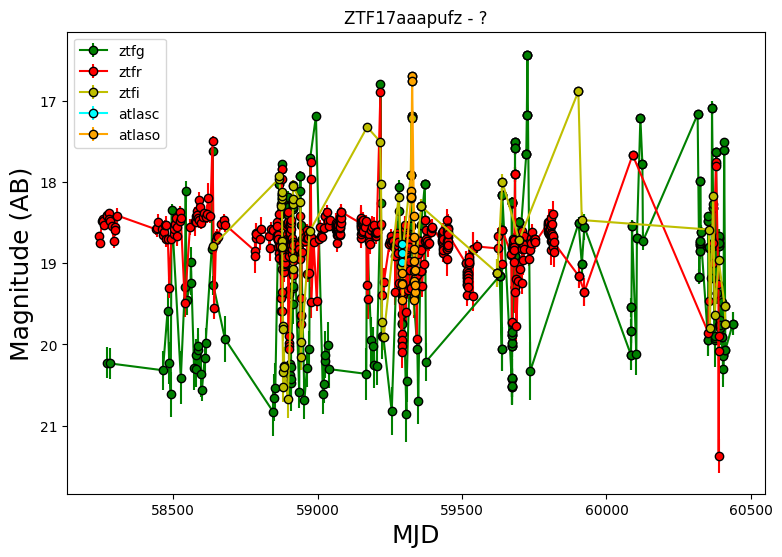

In [173]:
plot_data.plot_photometry(photo_df)

In [183]:
from astropy.io import fits
import gzip
import io

def decompress_fits(data):
    compressed_data = gzip.decompress(data)
    with fits.open(io.BytesIO(compressed_data), ignore_missing_end=True) as hdul:
        return hdul[0].data

def process_alert(alert):
    # metadata
    metadata = alert['candidate']
    metadata_df = pd.DataFrame([metadata])
    metadata_df['objectId'] = alert['objectId']
    columns_metadata = [
        "objectId",
        "sgscore1", "sgscore2", 
        "distpsnr1", "distpsnr2", 
        "fwhm", 
        "magpsf", 
        "sigmapsf", 
        "ra", 
        "dec", 
        "diffmaglim", 
        "ndethist", 
        "nmtchps", 
        "ncovhist", 
        "sharpnr", 
        "scorr", 
        "sky"
    ]
    metadata_df = metadata_df[columns_metadata]

    # images
    cutout_science = decompress_fits(alert['cutoutScience']['stampData'])
    cutout_template = decompress_fits(alert['cutoutTemplate']['stampData'])
    cutout_difference = decompress_fits(alert['cutoutDifference']['stampData'])

    assembled_image = np.stack((cutout_science, cutout_template, cutout_difference), axis=-1)

    return metadata_df, assembled_image

In [190]:
def get_first_valid_index(photometry, object_alertes):
    for i, alert in enumerate(object_alertes):
        jd_current = alert['candidate']['jd']
        photometry_filtered = photometry[photometry['jd'] < jd_current]

        filters_to_check = ['ztfr', 'ztfg', 'ztfi']
        for filt in filters_to_check:
            if (photometry_filtered['filter'] == filt).sum() >= 3:
                return i
    
    return -1

def cut_photometry(photometry, object_alertes, index):
    jd_current = object_alertes[index]['candidate']['jd']
    photometry_filtered = photometry[photometry['jd'] < jd_current]
    return photometry_filtered

def get_data(photometry, object_alerts, index=0):

    first_index = get_first_valid_index(photometry, object_alerts)
    if first_index == -1:
        return None, None
    
    if index < first_index:
        index = first_index

    photometry_filtered = cut_photometry(photometry, object_alerts, index)
    alert = object_alerts[index]

    metadata_df, assembled_image = process_alert(alert)
    return photometry_filtered, metadata_df, assembled_image

In [191]:
photo_1, metatda_df, images = get_data(photo_df, object_alerts)

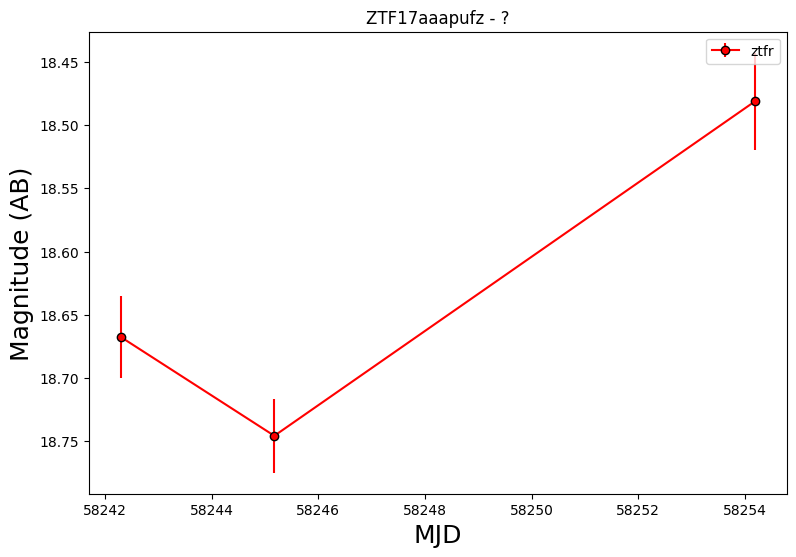

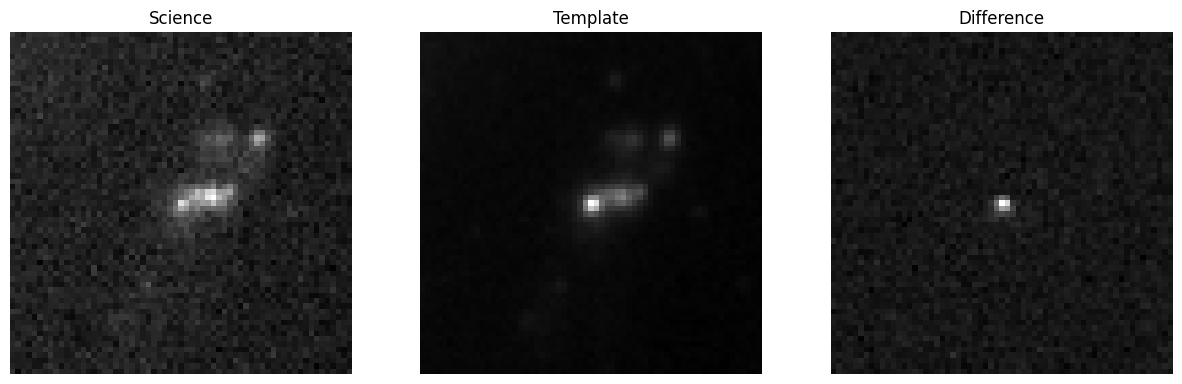

       objectId  sgscore1  sgscore2  distpsnr1  distpsnr2  fwhm     magpsf  \
0  ZTF17aaapufz   0.06775       0.5   0.086062   0.999845  2.13  18.474344   

   sigmapsf         ra        dec  diffmaglim  ndethist  nmtchps  ncovhist  \
0  0.037255  188.96785  27.932071   20.660788        64       19        93   

   sharpnr      scorr       sky  
0    0.173  34.774063 -0.516451  


In [193]:
plot_data.plot_all(photo_1, metatda_df, images)

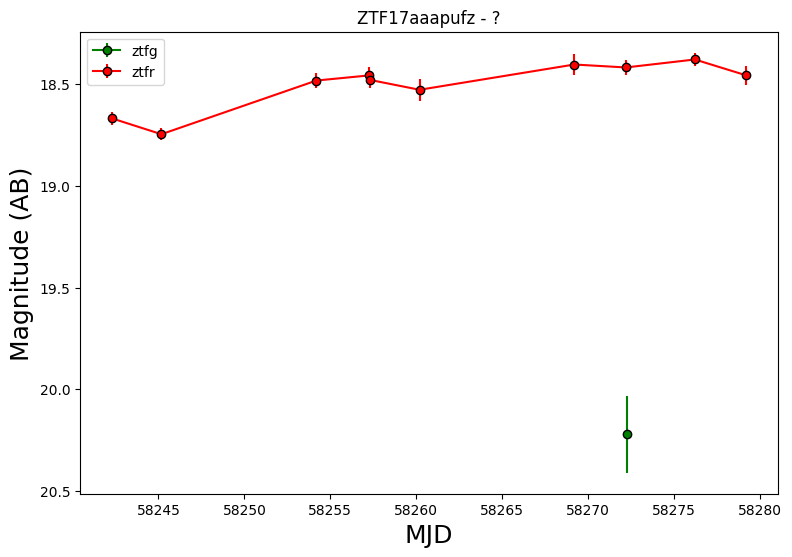

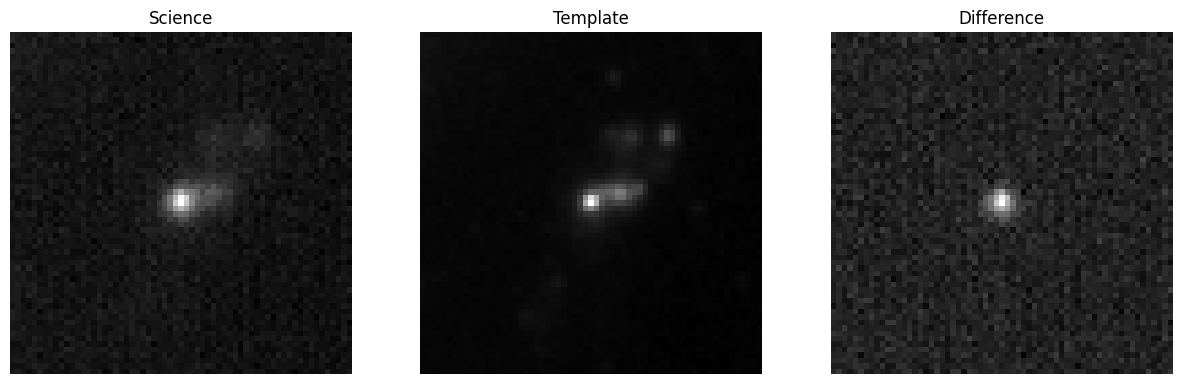

       objectId  sgscore1  sgscore2  distpsnr1  distpsnr2  fwhm     magpsf  \
0  ZTF17aaapufz   0.06775       0.5   0.229796   0.849283  4.12  17.663441   

   sigmapsf          ra       dec  diffmaglim  ndethist  nmtchps  ncovhist  \
0  0.053138  188.967881  27.93204    19.78352      1023       19      1967   

   sharpnr      scorr      sky  
0    0.173  35.413357 -0.44951  


In [195]:
photo_df, metatda_df, images = get_data(photo_df, object_alerts, index=900)
plot_data.plot_all(photo_df, metatda_df, images)

In [29]:
alerts = np.arange(1, 101)
initial_prob = 0.5

predict_sn = initial_prob + (np.linspace(0, 1, 100) - 0.5) * np.random.uniform(0.5, 1, 100)
predict_sn = np.clip(predict_sn, 0, 1)
predict_sn = np.round(predict_sn, 2)
predict_other = 1 - predict_sn
predict_other = np.round(predict_other, 2)  

df = pd.DataFrame({
    'alertes': alerts,
    'predict_sn': predict_sn,
    'predict_other': predict_other
})

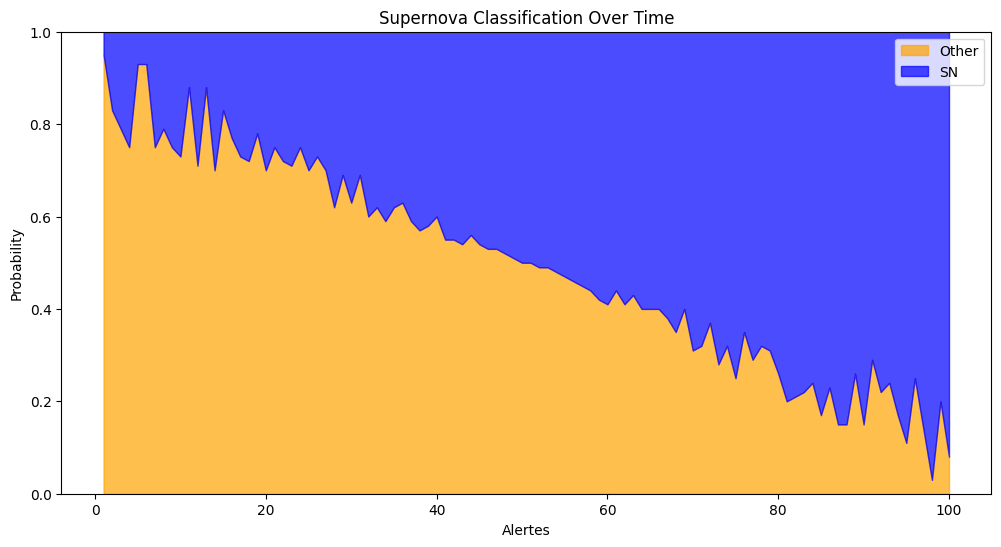

In [30]:
plot_evaluation.plot_supernova_classification(df)

In [31]:
plot_evaluation.plot_interactive_supernova_classification(df)